## Problem Statement

This tutorial takes a practical and coding-focused approach. We'll learn how to use _decision trees_ and _random forests_ to solve a real-world problem from [Kaggle](https://kaggle.com/datasets):

> **QUESTION**: The [Rain in Australia dataset](https://kaggle.com/jsphyg/weather-dataset-rattle-package) contains about 10 years of daily weather observations from numerous Australian weather stations. Here's a small sample from the dataset:
> 
> ![](https://i.imgur.com/5QNJvir.png)
>
> As a data scientist at the Bureau of Meteorology, you are tasked with creating a fully-automated system that can use today's weather data for a given location to predict whether it will rain at the location tomorrow. 
>
>
> ![](https://i.imgur.com/KWfcpcO.png)

In [86]:
!pip install opendatasets pandas numpy sklearn jovian -- quit

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag

In [87]:
!pip install scikit-learn
!pip install jovian


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [88]:
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = "#12DAF500"

In [89]:
od.download('https://www.kaggle.com/jsphyg/weather-dataset-rattle-package')

Skipping, found downloaded files in ".\weather-dataset-rattle-package" (use force=True to force download)


In [90]:
os.listdir('weather-dataset-rattle-package')

['weatherAUS.csv']

In [91]:
raw_df = pd.read_csv("weather-dataset-rattle-package/weatherAUS.csv")

In [92]:
raw_df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


Each row shows the measurements for a given date at a given location. The last column "RainTomorrow" contains the value to be predicted.

Let's check the column types of the dataset

In [93]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [94]:
raw_df.dropna(subset=['RainTomorrow'], inplace=True)

## Preparing the Data for Training

We'll perform the following steps to prepare the dataset for training:

1. Create a train/test/validation split
2. Identify input and target columns
3. Identify numeric and categorical columns
4. Impute (fill) missing numeric values
5. Scale numeric values to the $(0, 1)$ range
6. Encode categorical columns to one-hot vectors

### Training, Validation and Test Sets

<Axes: title={'center': 'No. of Rows per year'}, xlabel='Date', ylabel='count'>

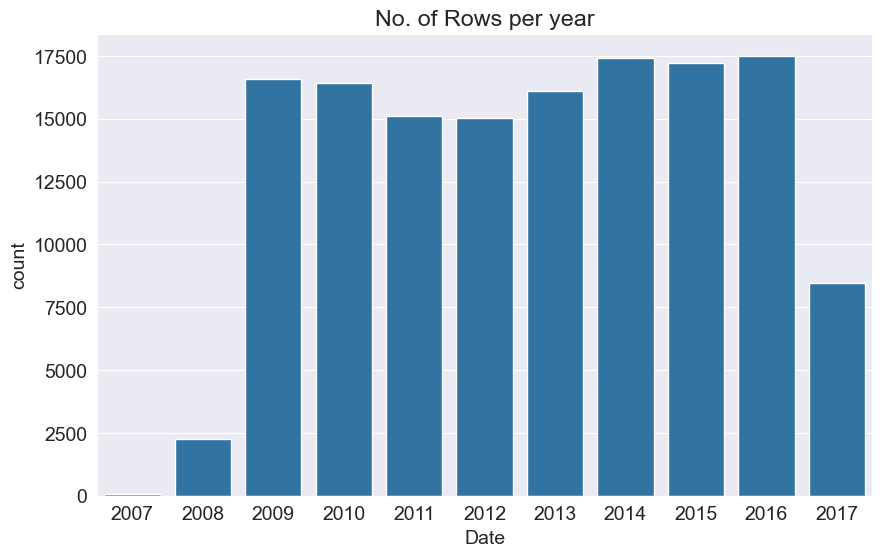

In [95]:
plt.title("No. of Rows per year")
sns.countplot(x=pd.to_datetime(raw_df['Date']).dt.year, data=raw_df)

In [96]:
year = pd.to_datetime(raw_df['Date']).dt.year
train_df = raw_df[year < 2015]
val_df = raw_df[year == 2015]
test_df = raw_df[year > 2015]

In [97]:
print(train_df.shape, val_df.shape, test_df.shape)

(98988, 23) (17231, 23) (25974, 23)


### Input and Target Columns

Let's identify the input and target columns.

In [98]:
input_cols = list(train_df.columns)[1:-1]
target_col = 'RainTomorrow' 

In [99]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [100]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [101]:
test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_col].copy()

Let's also identify the numeric and categorical columns.

In [102]:
numeric_cols = train_inputs.select_dtypes(include=['number']).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=['object', 'bool']).columns.tolist()

In [103]:
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Categorical columns: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


### Imputing missing numeric values

In [104]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
imputer.fit(train_inputs[numeric_cols])

,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [105]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [106]:
test_inputs[numeric_cols].isna().sum()

MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
dtype: int64

### Scaling Numeric Features

In [107]:
from sklearn.preprocessing import  MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train_inputs[numeric_cols]) 

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [108]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [109]:
val_inputs.describe().loc[['min', 'max']]

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
min,-8.2,-3.2,0.0,0.0,0.0,7.0,0.0,0.0,4.0,0.0,988.1,982.2,0.0,0.0,-6.2,-4.0
max,31.9,45.4,247.2,70.4,14.5,135.0,87.0,74.0,100.0,100.0,1039.3,1037.3,8.0,8.0,37.5,42.8


### Encoding Categorical Data

In [110]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [111]:
encoded_train = encoder.transform(train_inputs[categorical_cols])
encoded_val   = encoder.transform(val_inputs[categorical_cols])
encoded_test  = encoder.transform(test_inputs[categorical_cols])

In [112]:
train_inputs[encoded_cols] = encoded_train
val_inputs[encoded_cols]   = encoded_val
test_inputs[encoded_cols]  = encoded_test

C:\Users\SUDEB BAG\AppData\Local\Temp\ipykernel_816\1674039154.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols] = encoded_train
C:\Users\SUDEB BAG\AppData\Local\Temp\ipykernel_816\1674039154.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols] = encoded_train
C:\Users\SUDEB BAG\AppData\Local\Temp\ipykernel_816\1674039154.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

In [113]:
# Final model inputs
X_train = train_inputs[numeric_cols + encoded_cols]
X_val   = val_inputs[numeric_cols + encoded_cols]
X_test  = test_inputs[numeric_cols + encoded_cols]

In [114]:
X_test.head(10)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Location_Adelaide,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,Location_Cobar,Location_CoffsHarbour,Location_Dartmoor,Location_Darwin,Location_GoldCoast,Location_Hobart,Location_Katherine,Location_Launceston,Location_Melbourne,Location_MelbourneAirport,Location_Mildura,Location_Moree,Location_MountGambier,Location_MountGinini,Location_Newcastle,Location_Nhil,Location_NorahHead,Location_NorfolkIsland,Location_Nuriootpa,Location_PearceRAAF,Location_Penrith,Location_Perth,Location_PerthAirport,Location_Portland,Location_Richmond,Location_Sale,Location_SalmonGums,Location_Sydney,Location_SydneyAirport,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,WindGustDir_E,WindGustDir_ENE,WindGustDir_ESE,WindGustDir_N,WindGustDir_NE,WindGustDir_NNE,WindGustDir_NNW,WindGustDir_NW,WindGustDir_S,WindGustDir_SE,WindGustDir_SSE,WindGustDir_SSW,WindGustDir_SW,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW,WindGustDir_nan,WindDir9am_E,WindDir9am_ENE,WindDir9am_ESE,WindDir9am_N,WindDir9am_NE,WindDir9am_NNE,WindDir9am_NNW,WindDir9am_NW,WindDir9am_S,WindDir9am_SE,WindDir9am_SSE,WindDir9am_SSW,WindDir9am_SW,WindDir9am_W,WindDir9am_WNW,WindDir9am_WSW,WindDir9am_nan,WindDir3pm_E,WindDir3pm_ENE,WindDir3pm_ESE,WindDir3pm_N,WindDir3pm_NE,WindDir3pm_NNE,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes,RainToday_nan
2498,20.4,37.6,0.0,5.28686,7.602136,54.0,0.0,7.0,46.0,17.0,1013.4,1009.2,7.000000,3.000000,26.1,36.7,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2499,20.9,33.6,0.4,5.28686,7.602136,50.0,9.0,17.0,54.0,30.0,1011.1,1008.4,8.000000,8.000000,24.8,31.7,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2500,18.4,23.1,2.2,5.28686,7.602136,48.0,11.0,39.0,62.0,67.0,1014.0,1014.8,8.000000,8.000000,21.8,19.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2501,17.3,23.7,15.6,5.28686,7.602136,39.0,9.0,17.0,74.0,65.0,1017.9,1016.5,8.000000,8.000000,19.2,21.6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2502,15.5,22.9,6.8,5.28686,7.602136,31.0,6.0,9.0,92.0,63.0,1016.3,1013.9,

In [115]:
X_test.tail(10)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Location_Adelaide,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,Location_Cobar,Location_CoffsHarbour,Location_Dartmoor,Location_Darwin,Location_GoldCoast,Location_Hobart,Location_Katherine,Location_Launceston,Location_Melbourne,Location_MelbourneAirport,Location_Mildura,Location_Moree,Location_MountGambier,Location_MountGinini,Location_Newcastle,Location_Nhil,Location_NorahHead,Location_NorfolkIsland,Location_Nuriootpa,Location_PearceRAAF,Location_Penrith,Location_Perth,Location_PerthAirport,Location_Portland,Location_Richmond,Location_Sale,Location_SalmonGums,Location_Sydney,Location_SydneyAirport,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,WindGustDir_E,WindGustDir_ENE,WindGustDir_ESE,WindGustDir_N,WindGustDir_NE,WindGustDir_NNE,WindGustDir_NNW,WindGustDir_NW,WindGustDir_S,WindGustDir_SE,WindGustDir_SSE,WindGustDir_SSW,WindGustDir_SW,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW,WindGustDir_nan,WindDir9am_E,WindDir9am_ENE,WindDir9am_ESE,WindDir9am_N,WindDir9am_NE,WindDir9am_NNE,WindDir9am_NNW,WindDir9am_NW,WindDir9am_S,WindDir9am_SE,WindDir9am_SSE,WindDir9am_SSW,WindDir9am_SW,WindDir9am_W,WindDir9am_WNW,WindDir9am_WSW,WindDir9am_nan,WindDir3pm_E,WindDir3pm_ENE,WindDir3pm_ESE,WindDir3pm_N,WindDir3pm_NE,WindDir3pm_NNE,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes,RainToday_nan
145449,2.6,22.5,0.0,5.28686,7.602136,19.0,9.0,7.0,59.0,24.0,1025.0,1021.4,4.308048,4.414451,8.8,22.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145450,5.2,24.3,0.0,5.28686,7.602136,24.0,11.0,11.0,53.0,24.0,1023.8,1020.0,4.308048,4.414451,12.3,23.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145451,6.4,23.4,0.0,5.28686,7.602136,31.0,15.0,17.0,53.0,25.0,1025.8,1023.0,4.308048,4.414451,11.2,23.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145452,8.0,20.7,0.0,5.28686,7.602136,41.0,19.0,26.0,56.0,32.0,1028.1,1024.3,4.308048,7.000000,11.6,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145453,7.4,20.6,0.0,5.28686,7.602136,35.0,15.0,17.0,63.0,33.0,1027.2,

## Training and Visualizing Decision Trees

A decision tree in general parlance represents a hierarchical series of binary decisions:

<img src="https://i.imgur.com/qSH4lqz.png" width="480">

A decision tree in machine learning works in exactly the same way, and except that we let the computer figure out the optimal structure & hierarchy of decisions, instead of coming up with criteria manually.

### Training

We can use `DecisionTreeClassifier` from `sklearn.tree` to train a decision tree.

In [116]:
from sklearn.tree import DecisionTreeClassifier
model =  DecisionTreeClassifier(random_state=42)

In [117]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, train_targets)   # 👈 THIS LINE WAS MISSING

train_preds = model.predict(X_train)


### Evaluation

Let's evaluate the decision tree using the accuracy score.

In [118]:
from sklearn.metrics import accuracy_score, confusion_matrix  
train_preds = model.predict(X_train)
train_preds  

array(['No', 'No', 'No', ..., 'No', 'No', 'No'],
      shape=(98988,), dtype=object)

In [119]:
pd.value_counts(train_preds)

C:\Users\SUDEB BAG\AppData\Local\Temp\ipykernel_816\1258350197.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(train_preds)


No     76707
Yes    22281
Name: count, dtype: int64

In [120]:
train_probs = model.predict_proba(X_train)
train_probs

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]], shape=(98988, 2))

In [121]:
accuracy_score(train_targets, train_preds)

0.9999797955307714

The training set accuracy is close to 100%! But we can't rely solely on the training set accuracy, we must evaluate the model on the validation set too. 

We can make predictions and compute accuracy in one step using `model.score`

In [122]:
model.score(X_val, val_targets)

0.7915965411177529

Although the training accuracy is 100%, the accuracy on the validation set is just about 79%, which is only marginally better then always predicting "No". 

In [123]:
val_targets.value_counts() / len(val_targets)

RainTomorrow
No     0.788289
Yes    0.211711
Name: count, dtype: float64

It appears that the model has learned the training examples perfect, and doesn't generalize well to previously unseen examples. This phenomenon is called "overfitting", and reducing overfitting is one of the most important parts of any machine learning project.

### Visualization

We can visualize the decision tree _learned_ from the training data.

[Text(0.5, 0.875, 'Humidity3pm <= 71.5\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]'),
 Text(0.25, 0.625, 'Rainfall <= 1.5\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Sunshine <= 7.601\ngini = 0.198\nsamples = 69252\nvalue = [61538.0, 7714.0]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Humidity3pm <= 51.251\ngini = 0.438\nsamples = 13166\nvalue = [8901, 4265]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Humidity3pm <= 82.5\ngini = 0.47\nsamples = 16570\nvalue = [6266, 10304]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'WindGustSpeed <= 42.0\ngini = 0.499\nsamples = 9136\nvalue = [4804, 4332]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Rainfall <= 3.7\ngini = 0.316\nsamples = 7434\nvalue = [1462, 5972]'),
 Text(0.8125, 0.125, '\n 

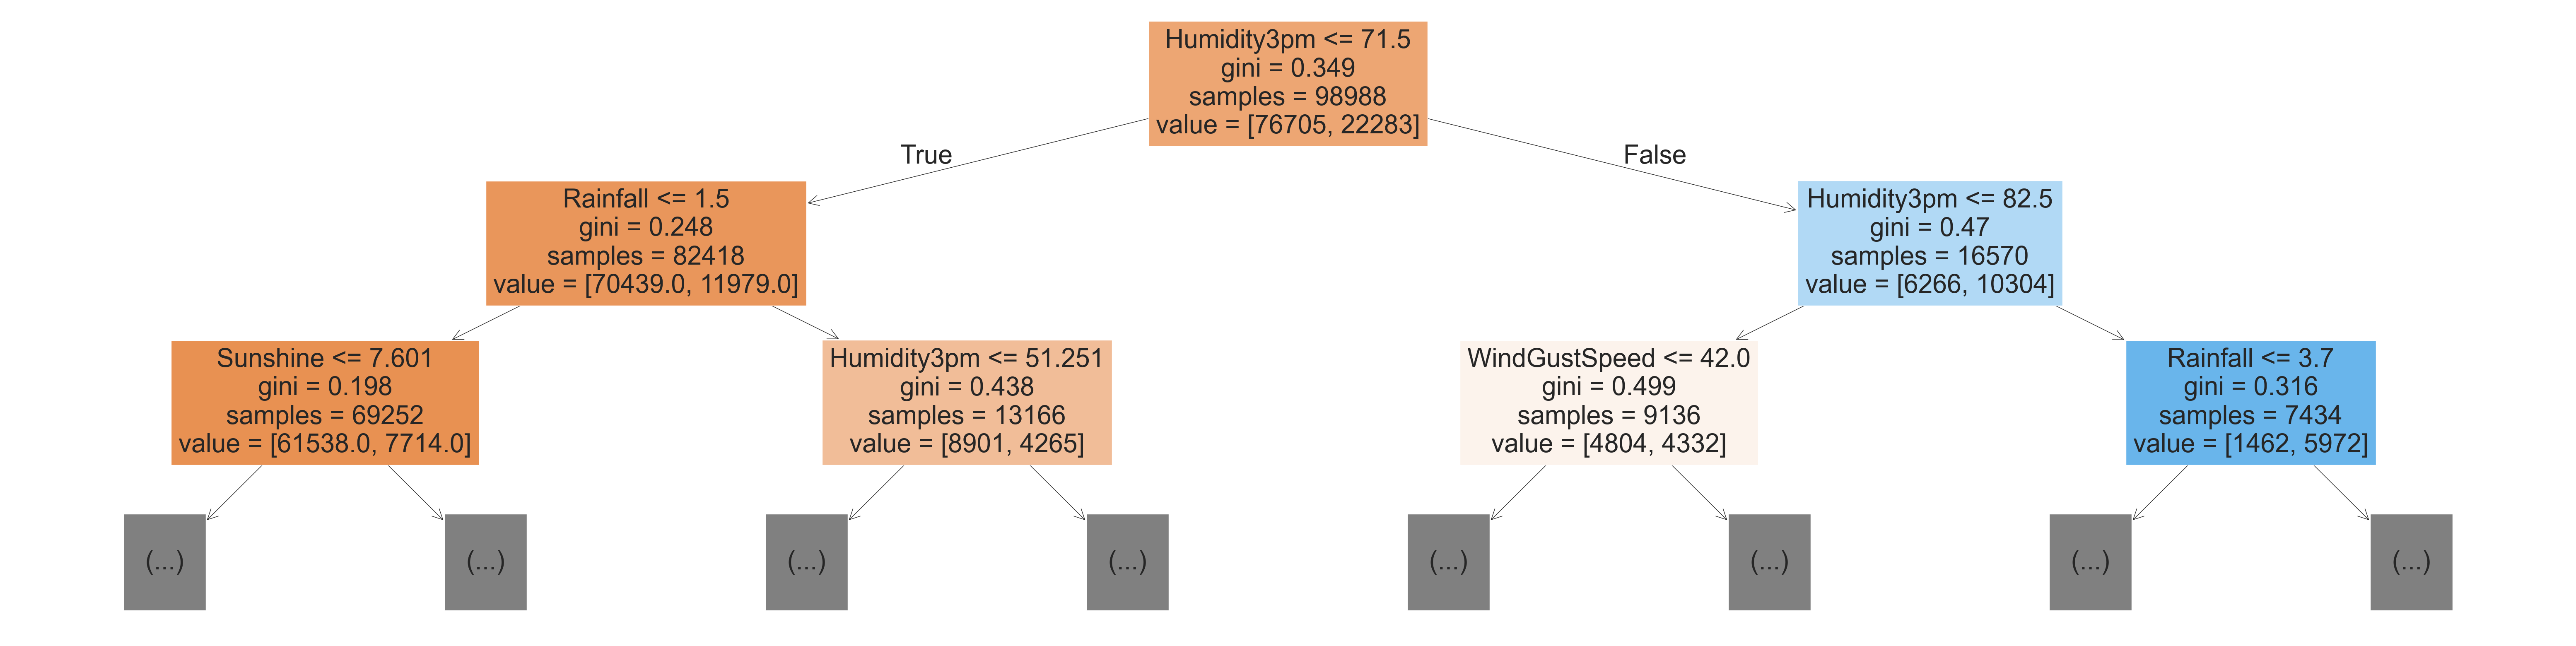

In [124]:
from sklearn.tree import plot_tree, export_text
plt.figure(figsize=(80,20))    
plot_tree(model,feature_names=X_train.columns, max_depth=2, filled = True)     

Can you see how the model classifies a given input as a series of decisions? The tree is truncated here, but following any path from the root node down to a leaf will result in "Yes" or "No". Do you see how a decision tree differs from a logistic regression model?


**How a Decision Tree is Created**

Note the `gini` value in each box. This is the loss function used by the decision tree to decide which column should be used for splitting the data, and at what point the column should be split. A lower Gini index indicates a better split. A perfect split (only one class on each side) has a Gini index of 0. 

For a mathematical discussion of the Gini Index, watch this video: https://www.youtube.com/watch?v=-W0DnxQK1Eo . It has the following formula:

<img src="https://i.imgur.com/CSC0gAo.png" width="240">

Conceptually speaking, while training the models evaluates all possible splits across all possible columns and picks the best one. Then, it recursively performs an optimal split for the two portions. In practice, however, it's very inefficient to check all possible splits, so the model uses a heuristic (predefined strategy) combined with some randomization.

The iterative approach of the machine learning workflow in the case of a decision tree involves growing the tree layer-by-layer:

<img src="https://www.deepnetts.com/blog/wp-content/uploads/2019/02/SupervisedLearning.png" width="480">


Let's check the depth of the tree that was created.

In [125]:
model.tree_.max_depth

48

We can also display the tree as text, which can be easier to follow for deeper trees.

In [126]:
tree_text = export_text(model, max_depth=10, feature_names=list(X_train.columns))
print(tree_text[:5000])

|--- Humidity3pm <= 71.50
|   |--- Rainfall <= 1.50
|   |   |--- Sunshine <= 7.60
|   |   |   |--- Pressure3pm <= 1013.55
|   |   |   |   |--- WindGustSpeed <= 53.00
|   |   |   |   |   |--- Humidity3pm <= 27.50
|   |   |   |   |   |   |--- WindDir9am_NE <= 0.50
|   |   |   |   |   |   |   |--- Location_Watsonia <= 0.50
|   |   |   |   |   |   |   |   |--- Cloud9am <= 7.50
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm <= 6.50
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm <= 1005.75
|   |   |   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm >  1005.75
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm >  6.50
|   |   |   |   |   |   |   |   |   |   |--- MinTemp <= 5.20
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |   |--- MinTemp >  5.20
|   |   |   |   |   |   |   |   |   |   |   |-

### Feature Importance

Based on the gini index computations, a decision tree assigns an "importance" value to each feature. These values can be used to interpret the results given by a decision tree.

In [127]:
model.feature_importances_

array([3.62010628e-02, 3.15410676e-02, 5.82546581e-02, 2.48322505e-02,
       5.08451879e-02, 5.48721143e-02, 2.68802557e-02, 3.04280561e-02,
       4.03337790e-02, 2.61055351e-01, 3.48742762e-02, 6.12186954e-02,
       1.31134817e-02, 1.92748524e-02, 3.34112355e-02, 2.99278458e-02,
       2.30948611e-03, 2.00269251e-03, 1.22618570e-03, 8.11664184e-04,
       1.56183476e-03, 1.09521007e-03, 6.53443035e-04, 1.63792732e-03,
       1.20114791e-03, 1.29168232e-03, 7.95286728e-04, 2.19922929e-03,
       1.74184984e-03, 2.68124067e-04, 1.18093830e-03, 1.59786025e-03,
       5.30953230e-04, 9.03108598e-04, 1.50171649e-03, 1.07133054e-03,
       8.07088742e-04, 8.03223575e-04, 1.79364244e-03, 2.09913294e-03,
       3.41903091e-04, 6.05150911e-04, 1.38447165e-03, 1.77902307e-03,
       1.35089758e-03, 8.51982460e-04, 6.83232777e-04, 1.56566910e-03,
       9.99683866e-04, 2.15218515e-03, 8.86321975e-04, 1.53907978e-03,
       8.71630249e-04, 1.28577975e-03, 1.60066700e-03, 5.28075720e-04,
      

Let's turn this into a dataframe and visualize the most important features.

Let's turn this into a dataframe and visualize the most important features.

In [128]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [129]:
importance_df.head(10)

,feature,importance
9,Humidity3pm,0.261055
11,Pressure3pm,0.061219
2,Rainfall,0.058255
5,WindGustSpeed,0.054872
4,Sunshine,0.050845
8,Humidity9am,0.040334
0,MinTemp,0.036201
10,Pressure9am,0.034874
14,Temp9am,0.033411
1,MaxTemp,0.031541


<Axes: title={'center': 'Feature Importances'}, xlabel='importance', ylabel='feature'>

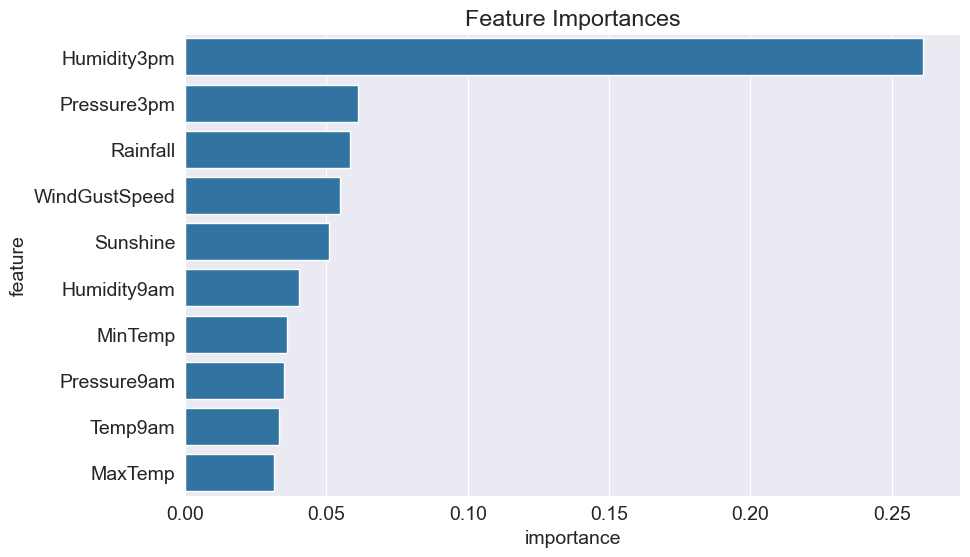

In [130]:
plt.title("Feature Importances")
sns.barplot(x='importance', y='feature', data=importance_df.head(10))

## Hyperparameter Tuning and Overfitting

As we saw in the previous section, our decision tree classifier memorized all training examples, leading to a 100% training accuracy, while the validation accuracy was only marginally better than a dumb baseline model. This phenomenon is called overfitting, and in this section, we'll look at some strategies for reducing overfitting.

The `DecisionTreeClassifier` accepts several arguments, some of which can be modified to reduce overfitting.

These arguments are called hyperparameters because they must be configured manually (as opposed to the parameters within the model which are _learned_ from the data. We'll explore a couple of hyperparameters:

- `max_depth`
- `max_leaf_nodes`

### `max_depth`

By reducing the maximum depth of the decision tree, we can prevent the tree from memorizing all training examples, which may lead to better generalization

In [131]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, train_targets)
model.score(X_train, train_targets)
model.score(X_val, val_targets)

0.8334397307178921

In [132]:
model.classes_

array(['No', 'Yes'], dtype=object)

[Text(0.5, 0.875, 'Humidity3pm <= 71.5\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]\nclass = No'),
 Text(0.25, 0.625, 'Rainfall <= 1.5\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]\nclass = No'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Sunshine <= 7.601\ngini = 0.198\nsamples = 69252\nvalue = [61538.0, 7714.0]\nclass = No'),
 Text(0.0625, 0.125, 'gini = 0.363\nsamples = 12620\nvalue = [9618, 3002]\nclass = No'),
 Text(0.1875, 0.125, 'gini = 0.153\nsamples = 56632\nvalue = [51920, 4712]\nclass = No'),
 Text(0.375, 0.375, 'Humidity3pm <= 51.251\ngini = 0.438\nsamples = 13166\nvalue = [8901, 4265]\nclass = No'),
 Text(0.3125, 0.125, 'gini = 0.293\nsamples = 4299\nvalue = [3531, 768]\nclass = No'),
 Text(0.4375, 0.125, 'gini = 0.478\nsamples = 8867\nvalue = [5370, 3497]\nclass = No'),
 Text(0.75, 0.625, 'Humidity3pm <= 82.5\ngini = 0.47\nsamples = 16570\nvalue = [6266, 10304]\nclass = Yes'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'WindGustSpeed

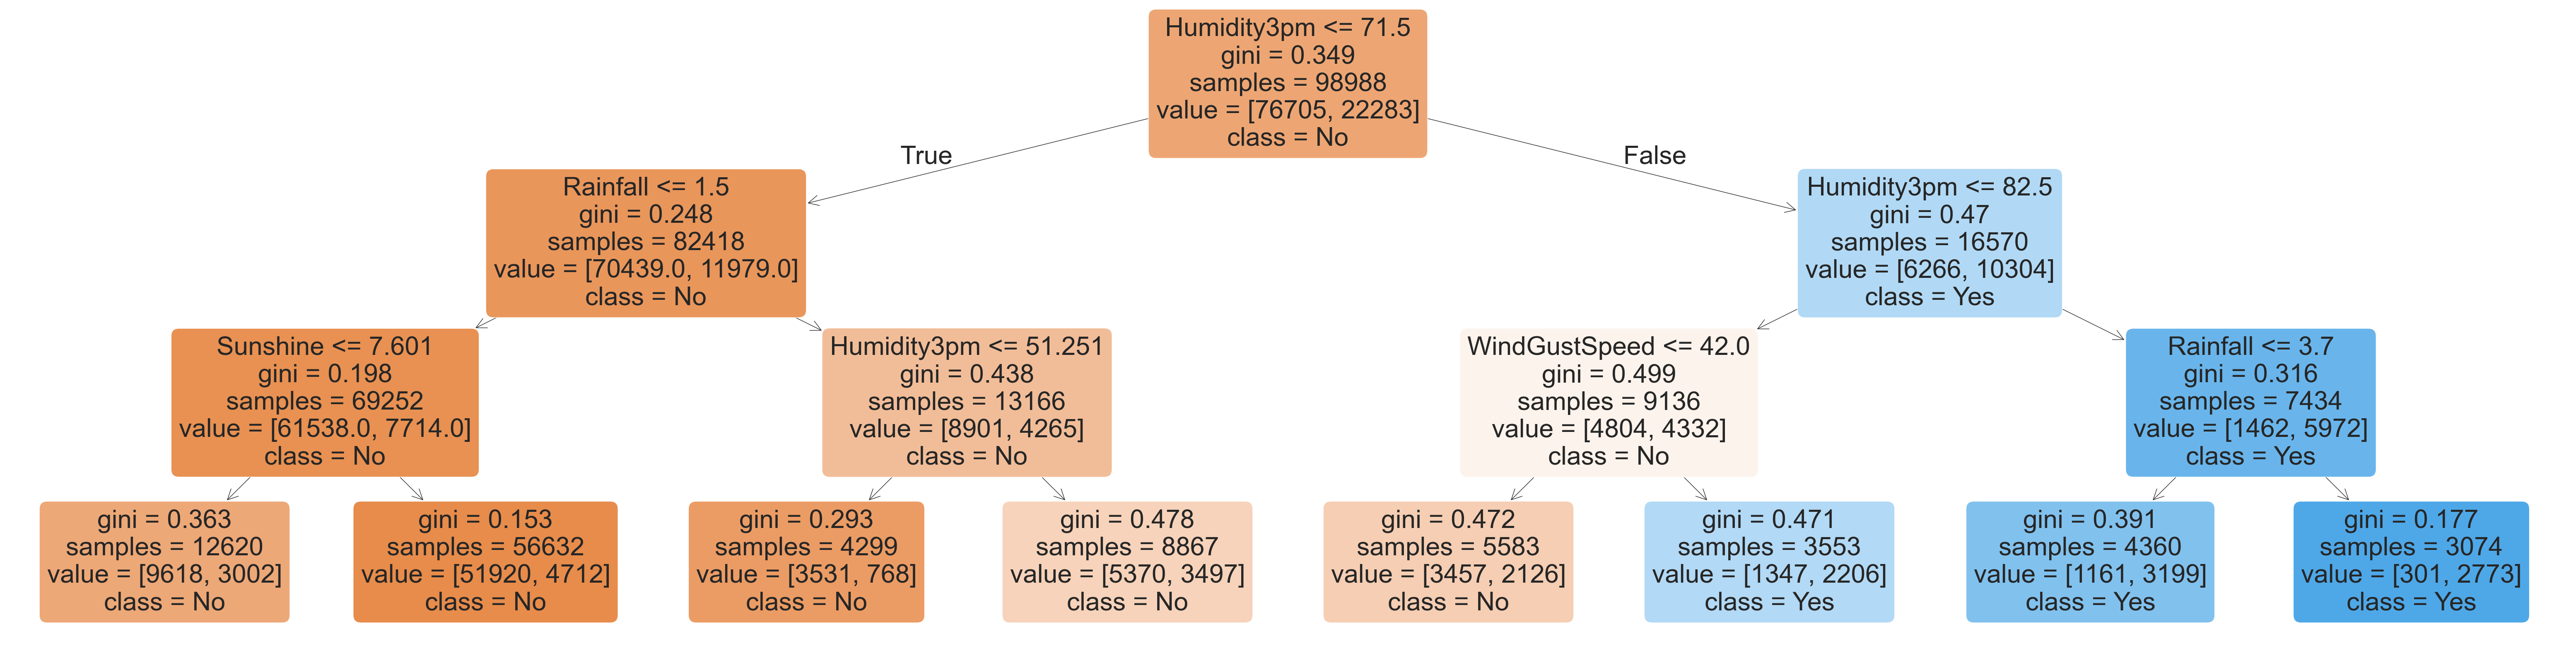

In [133]:
plt.figure(figsize=(80, 20))
plot_tree(model,feature_names=X_train.columns,  filled = True, rounded=True, class_names=model.classes_)

In [134]:
print(export_text(model, feature_names=list(X_train.columns)))

|--- Humidity3pm <= 71.50
|   |--- Rainfall <= 1.50
|   |   |--- Sunshine <= 7.60
|   |   |   |--- class: No
|   |   |--- Sunshine >  7.60
|   |   |   |--- class: No
|   |--- Rainfall >  1.50
|   |   |--- Humidity3pm <= 51.25
|   |   |   |--- class: No
|   |   |--- Humidity3pm >  51.25
|   |   |   |--- class: No
|--- Humidity3pm >  71.50
|   |--- Humidity3pm <= 82.50
|   |   |--- WindGustSpeed <= 42.00
|   |   |   |--- class: No
|   |   |--- WindGustSpeed >  42.00
|   |   |   |--- class: Yes
|   |--- Humidity3pm >  82.50
|   |   |--- Rainfall <= 3.70
|   |   |   |--- class: Yes
|   |   |--- Rainfall >  3.70
|   |   |   |--- class: Yes



In [135]:
def max_depth_error(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, train_targets)
    train_acc = 1 - model.score(X_train, train_targets)
    val_acc = 1 - model.score(X_val, val_targets)
    return {'Max Depth': md, 'Training Error': train_acc, 'Validation Error': val_acc}

In [136]:
%%time 
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])

CPU times: total: 39.8 s
Wall time: 41.1 s


In [137]:
errors_df

,Max Depth,Training Error,Validation Error
0,1,0.184315,0.177935
1,2,0.179547,0.172712
2,3,0.170869,0.166560
3,4,0.165707,0.164355
4,5,0.160676,0.159074
5,6,0.156271,0.157275
6,7,0.153312,0.154605
7,8,0.147806,0.157913
8,9,0.140977,0.156288
9,10,0.132945,0.157797


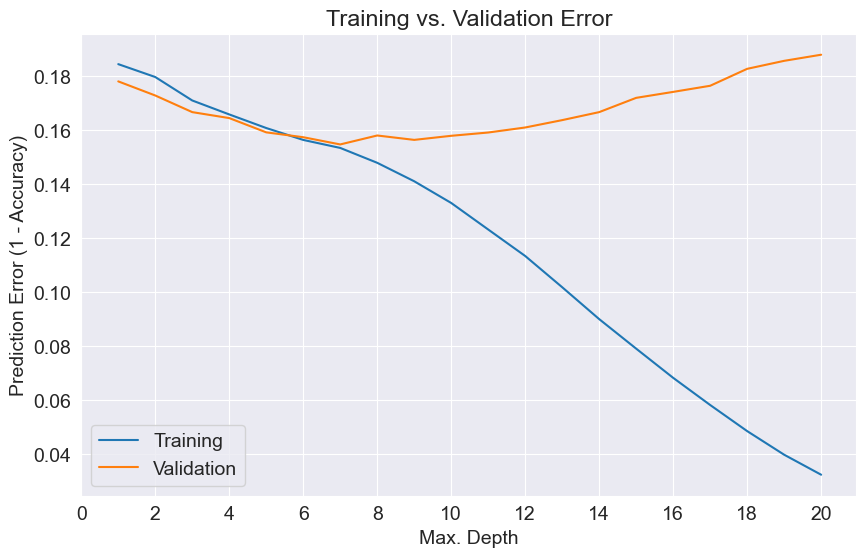

In [138]:
plt.figure()
plt.plot(errors_df['Max Depth'], errors_df['Training Error'])
plt.plot(errors_df['Max Depth'], errors_df['Validation Error'])
plt.title('Training vs. Validation Error')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])

This is a common pattern you'll see with all machine learning algorithms:

<img src="https://i.imgur.com/EJCrSZw.png" width="480">




You'll often need to tune hyperparameters carefully to find the optimal fit. In the above case, it appears that a maximum depth of 7 results in the lowest validation error.

In [139]:
model = DecisionTreeClassifier(max_depth=7, random_state=42)
model.fit(X_train, train_targets)

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [140]:
model.score(X_val, val_targets )

0.8453949277465034

### `max_leaf_nodes`

Another way to control the size of complexity of a decision tree is to limit the number of leaf nodes. This allows branches of the tree to have varying depths. 

In [141]:
model = DecisionTreeClassifier(max_leaf_nodes=128, random_state=42)

In [142]:
model.fit(X_train, train_targets)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,128
,min_impurity_decrease,0.0
,class_weight,None


In [143]:
model.score(X_train, train_targets)

0.8480421869317493

In [144]:
model.score(X_val, val_targets )

0.8442342290058615

In [145]:
model.tree_.max_depth

12

In [146]:
model_text = export_text(model, max_depth=10, feature_names=list(X_train.columns))
print(model_text[:3000])

|--- Humidity3pm <= 71.50
|   |--- Rainfall <= 1.50
|   |   |--- Sunshine <= 7.60
|   |   |   |--- Pressure3pm <= 1013.55
|   |   |   |   |--- WindGustSpeed <= 53.00
|   |   |   |   |   |--- Humidity3pm <= 27.50
|   |   |   |   |   |   |--- class: No
|   |   |   |   |   |--- Humidity3pm >  27.50
|   |   |   |   |   |   |--- Sunshine <= 0.75
|   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |--- Sunshine >  0.75
|   |   |   |   |   |   |   |--- Pressure3pm <= 1004.15
|   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |--- Pressure3pm >  1004.15
|   |   |   |   |   |   |   |   |--- Humidity3pm <= 57.50
|   |   |   |   |   |   |   |   |   |--- WindDir9am_NE <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- WindDir9am_NNE <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |   |--- WindDir9am_NNE >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   

## Training a Random Forest

While tuning the hyperparameters of a single decision tree may lead to some improvements, a much more effective strategy is to combine the results of several decision trees trained with slightly different parameters. This is called a random forest. 

The key idea here is that each decision tree in the forest will make different kinds of errors, and upon averaging, many of their errors will cancel out. This idea is also known as the "wisdom of the crowd" in common parlance:

<img src="https://i.imgur.com/4Dg0XK4.png" width="480">

A random forest works by averaging/combining the results of several decision trees:

<img src="https://1.bp.blogspot.com/-Ax59WK4DE8w/YK6o9bt_9jI/AAAAAAAAEQA/9KbBf9cdL6kOFkJnU39aUn4m8ydThPenwCLcBGAsYHQ/s0/Random%2BForest%2B03.gif" width="640">


We'll use the `RandomForestClassifier` class from `sklearn.ensemble`.

In [147]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_jobs=-1, random_state=422)
model.fit(X_train, train_targets)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [148]:
%%time
model.score(X_train, train_targets)

CPU times: total: 4.28 s
Wall time: 611 ms


0.9999393865923142

In [149]:
model.score(X_train, train_targets)

0.9999393865923142

In [150]:
model.score(X_val, val_targets)

0.8573501247751146

Once again, the training accuracy is 100%, but this time the validation accuracy is much better. In fact, it is better than the best single decision tree we had trained so far. Do you see the power of random forests?

This general technique of combining the results of many models is called "ensembling", it works because most errors of individual models cancel out on averaging. Here's what it looks like visually:

<img src="https://i.imgur.com/qJo8D8b.png" width="480">


We can also look at the probabilities for the predictions. The probability of a class is simply the fraction of trees which that predicted the given class.

In [151]:
train_probs = model.predict_proba(X_train)
train_probs

array([[0.98, 0.02],
       [0.98, 0.02],
       [0.97, 0.03],
       ...,
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.95, 0.05]], shape=(98988, 2))

We can can access individual decision trees using `model.estimators_`

In [152]:
model.estimators_[0]

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,1061963978
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.875, 'Humidity9am <= 75.5\ngini = 0.351\nsamples = 62715\nvalue = [76510, 22478]\nclass = No'),
 Text(0.25, 0.625, 'Sunshine <= 7.15\ngini = 0.254\nsamples = 39225\nvalue = [52760, 9235]\nclass = No'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Cloud3pm <= 7.5\ngini = 0.461\nsamples = 6291\nvalue = [6387.0, 3600.0]\nclass = No'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Location_MountGinini <= 0.5\ngini = 0.193\nsamples = 32934\nvalue = [46373, 5635]\nclass = No'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'WindDir9am_nan <= 0.5\ngini = 0.46\nsamples = 23490\nvalue = [23750, 13243]\nclass = No'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Cloud3pm <= 6.5\ngini = 0.47\nsamples = 20526\nvalue = [20156, 12255]\nclass = No'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Sunshine <= 3.45\ngini = 0

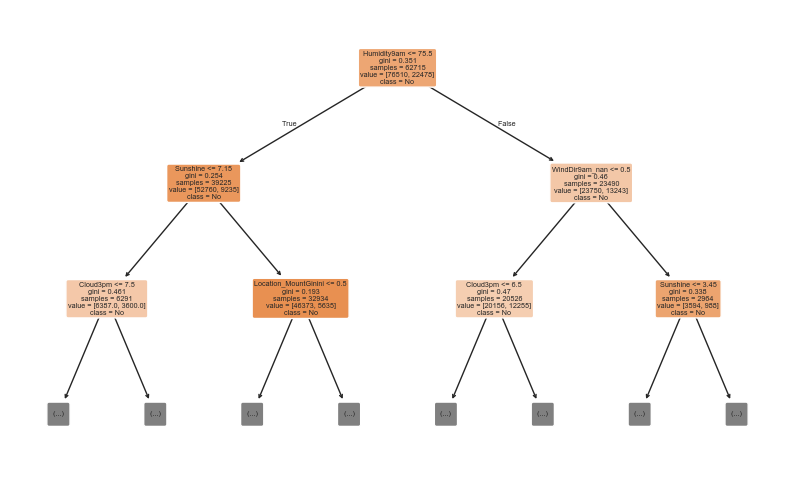

In [153]:
plt.Figure(figsize=(80, 20))
plot_tree(model.estimators_[0],max_depth=2, feature_names=X_train.columns,  filled = True, rounded=True, class_names=model.classes_)

[Text(0.5, 0.875, 'Humidity3pm <= 71.5\ngini = 0.349\nsamples = 62637\nvalue = [76717, 22271]\nclass = No'),
 Text(0.25, 0.625, 'RainToday_No <= 0.5\ngini = 0.247\nsamples = 52142\nvalue = [70536, 11882]\nclass = No'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'WindSpeed9am <= 19.5\ngini = 0.428\nsamples = 9165\nvalue = [9988, 4481]\nclass = No'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'WindGustDir_NW <= 0.5\ngini = 0.194\nsamples = 42977\nvalue = [60548, 7401]\nclass = No'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Humidity3pm <= 83.5\ngini = 0.468\nsamples = 10495\nvalue = [6181, 10389]\nclass = Yes'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'WindSpeed9am <= 21.0\ngini = 0.5\nsamples = 6167\nvalue = [4916, 4837]\nclass = No'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Location_Sydney <= 0.5\ngin

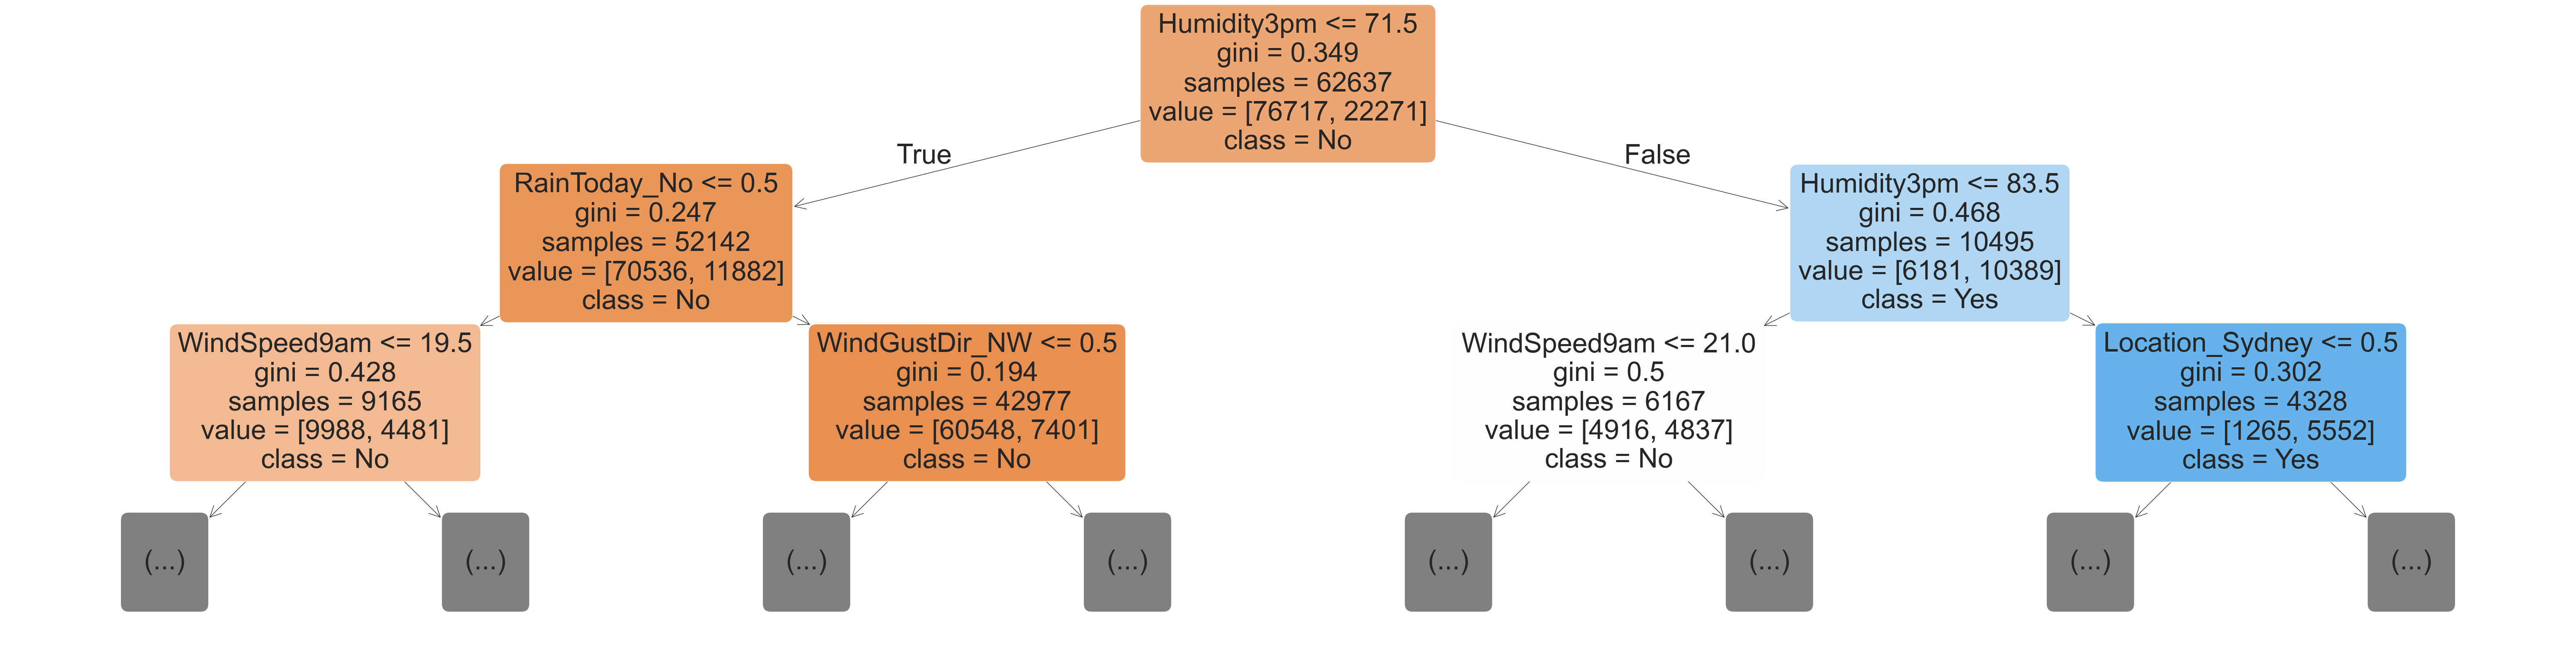

In [154]:
plt.figure(figsize=(80, 20))
plot_tree(model.estimators_[15], max_depth=2, feature_names=X_train.columns,  filled = True, rounded=True, class_names=model.classes_)

In [155]:
 len(model.estimators_)

100

Just like decision tree, random forests also assign an "importance" to each feature, by combining the importance values from individual trees.

In [156]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [157]:
importance_df.head(10)

,feature,importance
9,Humidity3pm,0.135217
4,Sunshine,0.052498
11,Pressure3pm,0.052193
8,Humidity9am,0.052000
2,Rainfall,0.050059
10,Pressure9am,0.049449
5,WindGustSpeed,0.047441
15,Temp3pm,0.045312
0,MinTemp,0.042367
1,MaxTemp,0.041350


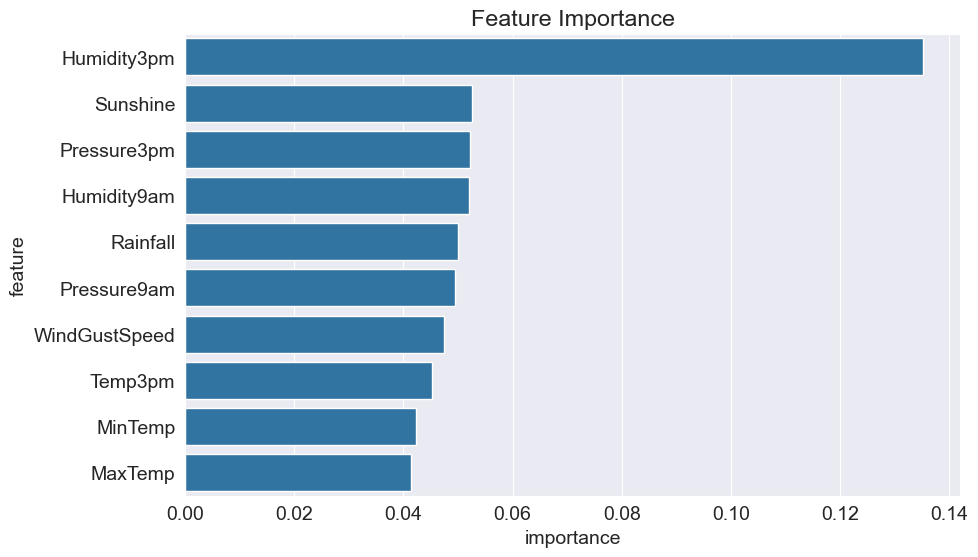

In [158]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

Notice that the distribution is a lot less skewed than that for a single decision tree.

## Hyperparameter Tuning with Random Forests

Just like decision trees, random forests also have several hyperparameters. In fact many of these hyperparameters are applied to the underlying decision trees. 

Let's study some the hyperparameters for random forests. You can learn more about them here: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Let's create a base model with which we can compare models with tuned hyperparameters.

In [159]:
base_model = RandomForestClassifier(random_state=42, n_jobs=-1).fit(X_train, train_targets)

In [160]:
base_train_acc = base_model.score(X_train, train_targets)
base_val_acc = base_model.score(X_val, val_targets)

In [161]:
base_accs = base_train_acc, base_val_acc
base_accs

(0.9999595910615429, 0.8560733561604086)

### `n_estimators`

This controls the number of decision trees in the random forest. The default value is 100. For larger datasets, it helps to have a greater number of estimators. As a general rule, try to have as few estimators as needed. 


**10 estimators**

In [162]:
model = RandomForestClassifier(n_estimators=10, random_state=42, n_jobs=-1)

In [163]:
model.fit(X_train, train_targets)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [164]:
model.score(X_train, train_targets)

0.9873722067321291

In [165]:
base_accs

(0.9999595910615429, 0.8560733561604086)

500 ESTIMATORS  

In [166]:
model = RandomForestClassifier(n_estimators=500,  n_jobs=-1, random_state=42,)
model.fit(X_train, train_targets)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [167]:
model.score(X_train, train_targets)

0.9999797955307714

In [168]:
model.score(X_val, val_targets)

0.8574661946491788

In [169]:
base_accs

(0.9999595910615429, 0.8560733561604086)

### `max_features`

Instead of picking all features for every split, we can specify only a fraction of features to be chosen randomly.

<img src="https://i.imgur.com/FXGWMDY.png" width="720">

Notice that the default value `auto` causes only $\sqrt{n}$ out of total features ( $n$ ) to be chosen randomly at each split. This is the reason each decision tree is in the forest is different. While it may seem counterintuitive, choosing all features for every split of every tree will lead to identical trees, so the random forest will not generalize well. 

In [172]:
test_params(max_features="log2")

(0.9999494888269285, 0.8557831814752481)

In [173]:
test_params(max_features=3)

(0.9999494888269285, 0.8506761070164239)

In [ ]:
test_params(max_features=6)

(0.9999494888269285, 0.8557831814752481)

In [174]:
base_accs

(0.9999595910615429, 0.8560733561604086)

### `max_depth` and `max_leaf_nodes`

These arguments are passed directly to each decision tree, and control the maximum depth and max. no leaf nodes of each tree respectively. By default, no maximum depth is specified, which is why each tree has a training accuracy of 100%. You can specify a `max_depth` to reduce overfitting.

<img src="https://i.imgur.com/EJCrSZw.png" width="480">

Let's define a helper function to `max depth`, `max_leaf_nodes` and other hyperparameters easily.

In [171]:
def test_params(**params):
    model = RandomForestClassifier(n_jobs=-1, random_state=42, **params)
    model.fit(X_train, train_targets)
    return model.score(X_train, train_targets), model.score(X_val, val_targets)

In [ ]:
test_params(max_depth = 5)

(0.8197559300117186, 0.8239800359816609)

In [175]:
test_params(max_depth = 25)

(0.9773305855255182, 0.8564215657826011)

In [176]:
test_params(max_leaf_nodes = 2**5)

(0.8314038065220026, 0.8335558005919563)

In [177]:
test_params(max_leaf_nodes = 2**20)

(0.9999595910615429, 0.8561894260344728)

In [178]:
base_accs

(0.9999595910615429, 0.8560733561604086)

### `min_samples_split` and `min_samples_leaf`

By default, the decision tree classifier tries to split every node that has 2 or more. You can increase the values of these arguments to change this behavior and reduce overfitting, especially for very large datasets.

In [179]:
test_params(min_samples_split=3, min_samples_leaf=2)

(0.9625409140501879, 0.8568278103418258)

In [180]:
test_params(min_samples_split=100, min_samples_leaf=60)

(0.8501333494969087, 0.8455109976205676)

In [181]:
base_accs

(0.9999595910615429, 0.8560733561604086)

### `min_impurity_decrease`

This argument is used to control the threshold for splitting nodes. A node will be split if this split induces a decrease of the impurity (Gini index) greater than or equal to this value. It's default value is 0, and you can increase it to reduce overfitting.


In [182]:
test_params(min_impurity_decrease=1e-6)

(0.9888774396896594, 0.8560153212233764)

In [183]:
test_params(min_impurity_decrease=1e-2)

(0.774891906089627, 0.7882885497069235)

In [184]:
base_accs

(0.9999595910615429, 0.8560733561604086)

### `bootstrap`, `max_samples` 

By default, a random forest doesn't use the entire dataset for training each decision tree. Instead it applies a technique called bootstrapping. For each tree, rows from the dataset are picked one by one randomly, with replacement i.e. some rows may not show up at all, while some rows may show up multiple times.


<img src="https://i.imgur.com/W8UGaEA.png" width="640">

Bootstrapping helps the random forest generalize better, because each decision tree only sees a fraction of th training set, and some rows randomly get higher weightage than others.

In [185]:
test_params(bootstrap=False)

(0.9999797955307714, 0.85694388021589)

In [186]:
base_accs

(0.9999595910615429, 0.8560733561604086)

When bootstrapping is enabled, you can also control the number or fraction of rows to be considered for each bootstrap using `max_samples`. This can further generalize the model.

<img src="https://i.imgur.com/rsdrL1W.png" width="640">

In [187]:
test_params(max_samples=0.9)

(0.9997777508384855, 0.8571179850269862)

In [188]:
base_accs

(0.9999595910615429, 0.8560733561604086)

### `class_weight`

In [189]:
model.classes_

array(['No', 'Yes'], dtype=object)

In [190]:
test_params(class_weight='balanced')

(0.9999595910615429, 0.8558412164122802)

In [191]:
test_params(class_weight={'No': 1, 'Yes': 2})

(0.9999494888269285, 0.8532876791828681)

In [192]:
base_accs

(0.9999595910615429, 0.8560733561604086)

### Putting it together

Let's train a random forest with customized hyperparameters based on our learnings. Of course, different hyperpraams

In [193]:
model = RandomForestClassifier(n_estimators=500, max_depth=30, random_state=42, max_features=7, n_jobs=-1, class_weight={'No': 1, 'Yes': 1.5})
model.fit(X_train, train_targets)

,n_estimators,500
,criterion,'gini'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [194]:
model.score(X_train, train_targets)

0.9920596435931628

In [195]:
base_accs

(0.9999595910615429, 0.8560733561604086)

We've increased the accuracy from 84.5% with a single decision tree to 85.7% with a well-tuned random forest. Depending on the dataset, you may or may not a see a significant improvement with hyperparameter tuning. This could be due to any of the following reasons:

- There simply may not be enough signal in the dataset. Whether it will rain tomorrow is an inherently uncertain outcome, and we can't predict it accurac

Let's also compute the accuracy of our final model on the test set.

In [196]:
model.score(X_test, test_targets)

0.8458073458073458

## Making Predictions on New Inputs

In [197]:
def predict_input(single_input):
    input_df = pd.DataFrame([single_input])
    
    input_df[numeric_cols] = imputer.transform(input_df[numeric_cols])
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    
    final_input = input_df[numeric_cols + encoded_cols]
    
    prediction = model.predict(final_input)[0]
    prediction_prob = model.predict_proba(final_input)[0][list(model.classes_).index(prediction)]
    
    return prediction, prediction_prob

In [200]:
sample = {
    'MinTemp': 15,
    'MaxTemp': 28,
    'Rainfall': 3.2,
    'Evaporation': 5.1,
    'Sunshine': 7.3,
    'WindGustDir': 'W',
    'WindGustSpeed': 45,
    'WindDir9am': 'NW',
    'WindDir3pm': 'W',
    'WindSpeed9am': 12,
    'WindSpeed3pm': 20,
    'Humidity9am': 65,
    'Humidity3pm': 40,
    'Pressure9am': 1012,
    'Pressure3pm': 1009,
    'Cloud9am': 5,
    'Cloud3pm': 3,
    'Temp9am': 20,
    'Temp3pm': 26,
    'RainToday': 'No',
    'Location': 'Sydney'
}

predict_input(sample)


C:\Users\SUDEB BAG\AppData\Local\Temp\ipykernel_816\2946517291.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
C:\Users\SUDEB BAG\AppData\Local\Temp\ipykernel_816\2946517291.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
C:\Users\SUDEB BAG\AppData\Local\Temp\ipykernel_816\2946517291.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

('No', np.float64(0.6508725637181411))